## Price Stimulation 
### - Monte Carlo Modelling of Resistance Breakouts

Author: Michelle Lin

This notebook implements a Monte Carlo simulation to study how a stochastic price process tests a resistance level multiple times before breaking out. It mirrors the intuition described in my Personal Statement, connecting probabilistic models with real-world price behaviour.

#### Step 1:
We start by importing the necessary libraries. To make our results reproducible and easier to debug, we fix the random seed so that the same random numbers are generated each time the code runs. For consistency and a cleaner look in the report, we also set a uniform graph size.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
# Ensure reproducibility
rng = np.random.default_rng(20)
# Matplotlib settings: set the graph size with no specific color/fontsize setting yet
plt.rcParams["figure.figsize"] = (8, 5)

In this part, I continue setting up the parameters based on the Geometric Brownian Motion (GBM) model, which can be written as 𝑑𝑆 = 𝜇𝑆 𝑑𝑡 + 𝜎𝑆 𝑑𝑊.

I also define what I mean by a ‘touch’ . This is important because I want to tell the difference between a price that just ‘touch’ the resistance level and one that actually ‘breaks through’ it.

In my setup, a price is considered to have ‘touched’ the resistance level when it enters the interval [𝑅 − 𝜖, 𝑅) without going above 𝑅. Here, 𝜖 defines a small tolerance margin near the resistance level to show how close the price needs to get to the resistance before I count it as a ‘touch’. 
I use this definition so that tiny numerical differences or random noise don’t make the model miss a valid touch.

In [16]:
# setting parameters (by using Geometric Brownian Motion)
S0 = 100.0 # initial price
R = 110.0 # resistance level
mu = 0.05 # annual drift
sigma = 0.25 # annual volatility (baseline)
T = 1.0 # time horizon in years
steps = 252 # number of trading days in a year
dt = T / steps
n_sims = 10000 # simulate 10000 paths
n_paths_preview = 20 # plot 20 of them for preview

# "Touch" definition
eps = 0.5 # price band width near resistance considered a "touch"

Next, I simulate asset price paths using the Geometric Brownian Motion (GBM) model. The idea of this implementation is based on an article from QuantStart (“Geometric Brownian Motion Simulation with Python”), but I modified and simplified the code so that it better fits the purpose of this project.

The class GeometricBrownianMotionSimulator generates price paths following the analytical solution of GBM: 𝑑𝑆 = 𝜇𝑆 𝑑𝑡 + 𝜎𝑆 𝑑𝑊

For each simulated path, random shocks drawn from a standard normal distribution are applied at each time step. By simulating multiple paths, we can visualize how different realizations of randomness affect the possible evolution of prices over time.
Finally, I plotted several of these simulated paths using Matplotlib to show how prices might move relative to the resistance level defined earlier.

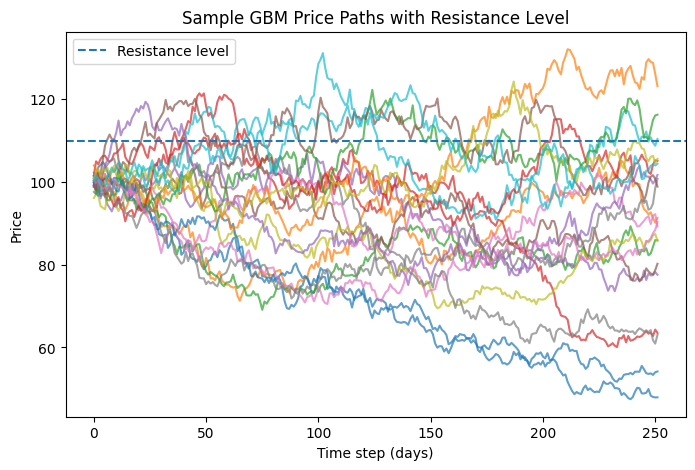

In [17]:
class GeometricBrownianMotionSimulator:
    def __init__(self, S0, mu, sigma, T, steps, rng):
        self.S0 = S0
        self.mu = mu
        self.sigma = sigma
        self.T = T
        self.steps = steps
        self.rng = rng
    def simulate_path(self):
        """
        Generates a single GBM path based on the initialized parameters.
        """
        dt = self.T / self.steps
        Z = self.rng.standard_normal(self.steps)
        increments = np.exp(
            (self.mu - 0.5 * self.sigma**2) * dt +
            self.sigma * np.sqrt(dt) * Z)
        path = self.S0 * np.cumprod(increments)
        return path
    
    def simulate_paths(self, n_paths):
        """
        Simulates multiple GBM paths.
        """
        return np.array([self.simulate_path() for _ in range(n_paths)])
    

# Initialize simulator with the same parameters defined earlier
gbm = GeometricBrownianMotionSimulator(S0, mu, sigma, T, steps, rng)

# Simulate multiple paths
S_preview = gbm.simulate_paths(n_paths_preview)

# Plot sample paths
plt.figure()
for i in range(n_paths_preview):
    plt.plot(S_preview[i], alpha=0.7)
    
plt.axhline(R, linestyle='--', label='Resistance level')
plt.title("Sample GBM Price Paths with Resistance Level")
plt.xlabel("Time step (days)")
plt.ylabel("Price")
plt.legend()
plt.show()

#### Step 2:
Here, I analyze the simulated price paths generated in the previous step to identify how many times a price touches the resistance band and whether it eventually breaks out above the resistance level. While the previous GBM simulator was responsible for generating the price data itself, this part focuses on interpreting that data. Specifically, the function analyze_path_touches_and_breakout() examines a single simulated price path and checks two things:

1. Touches — how many times the price enters the range [𝑅 − 𝜖, 𝑅) without crossing above 𝑅.
This represents moments when the price gets close to the resistance but doesn’t break it.

2. Breakout — whether the price eventually crosses the resistance level (𝑝𝑟𝑖𝑐𝑒 ≥ 𝑅), and if so, at which time step that first breakout occurs.
By running this analysis, I can distinguish between paths that repeatedly test the resistance level and those that actually manage to break through it.
This helps to better understand the behavior of simulated prices near key technical levels.

In [18]:
def analyze_path_touches_and_breakout(path, R, eps):
    """
    For a single price path (1D array), count number of 'touches' of the resistance band [R-eps, R)
before the first breakout (price >= R). Returns:
- touches: int
- broke_out: bool
- breakout_step: int or None
    """
    touches = 0
    broke_out = False
    breakout_step = None
    
    for t in range(1, len(path)): # iterate from first step
        price = path[t]
        if price >= R:
            broke_out = True
            breakout_step = t
            break
        # Count a "touch" when price is within [R - eps, R) and previous step was below the band
        
        prev = path[t-1]
        if (R - eps) <= price < R and (prev < R - eps):
            touches += 1
    return touches, broke_out, breakout_step

# Demonstrate on a single path from the preview set
sample_path = S_preview[0]
touches, broke_out, t_star = analyze_path_touches_and_breakout(sample_path, R,
eps)
print(f"Sample path: touches={touches}, broke_out={broke_out},breakout_step={t_star}")

Sample path: touches=0, broke_out=False,breakout_step=None


#### Step 3
In what follow, I extend the previous analysis into a ‘Monte Carlo simulation’. The idea is to repeat the GBM process many times — for example, 10,000 independent simulations — so that I can study the overall distribution of price behaviors rather than just one single path.

The function monte_carlo_touches_breakout() combines what I built in the previous stages. For each simulation, it first generates a price path based on the GBM model (from Stage 1), and then applies the touch and breakout detection logic (from Step 2).

By repeating this process over many runs, I can estimate statistical quantities such as:

• Breakout probability — the proportion of all simulated paths that eventually break above the resistance level.

• Average touches (all paths) — how many times, on average, prices come close to the resistance.

• Average touches (conditional on breakout) — how often prices touch the resistance before actually breaking it.

This Monte Carlo approach helps me move from analyzing one random outcome
to understanding the overall probability and frequency distribution of events across many possible scenarios.

The general idea of this simulation follows standard examples found in open educational resources such as QuantStart, but I wrote and adapted the implementation myself to fit this project.

In [19]:
def monte_carlo_touches_breakout(gbm, n_sims, R, eps):
    S = gbm.simulate_paths(n_sims)

    touches_arr = np.zeros(n_sims, dtype=int)
    breakout_arr = np.zeros(n_sims, dtype=bool)
    breakout_steps = np.full(n_sims, fill_value=-1, dtype=int)

    for i in range(n_sims):
        touches, broke_out, t_star = analyze_path_touches_and_breakout(
            S[i], R, eps
        )

        touches_arr[i] = touches
        breakout_arr[i] = broke_out
        breakout_steps[i] = t_star if t_star is not None else -1

    return touches_arr, breakout_arr, breakout_steps

touches_arr, breakout_arr, breakout_steps = monte_carlo_touches_breakout(
    gbm, n_sims, R, eps
)

breakout_prob = breakout_arr.mean()
avg_touches_all = touches_arr.mean()

avg_touches_cond = (
    touches_arr[breakout_arr].mean()
    if breakout_arr.any()
    else np.nan
)

print(f"Breakout probability within horizon: {breakout_prob:.3f}")
print(f"Average touches (all paths): {avg_touches_all:.2f}")
print(f"Average touches (conditional on breakout): {avg_touches_cond:.2f}")

Breakout probability within horizon: 0.688
Average touches (all paths): 0.29
Average touches (conditional on breakout): 0.40


#### Step 4 Visualisations

In this stage, I visualize the results obtained from the Monte Carlo simulations.

The goal is to better understand the statistical patterns observed in the previous analysis.

First, I plot a histogram of touch counts to show how many times, on average, prices touched the resistance band before either breaking out or finishing the time horizon.

From the chart, it is clear that most simulated paths have very few touches — in many cases, prices either never reach the resistance or break through it almost immediately.

Next, I explore the effect of volatility on the breakout probability and average number of touches.

By running the Monte Carlo simulation multiple times with different values, I can observe how randomness influences the likelihood of a breakout.

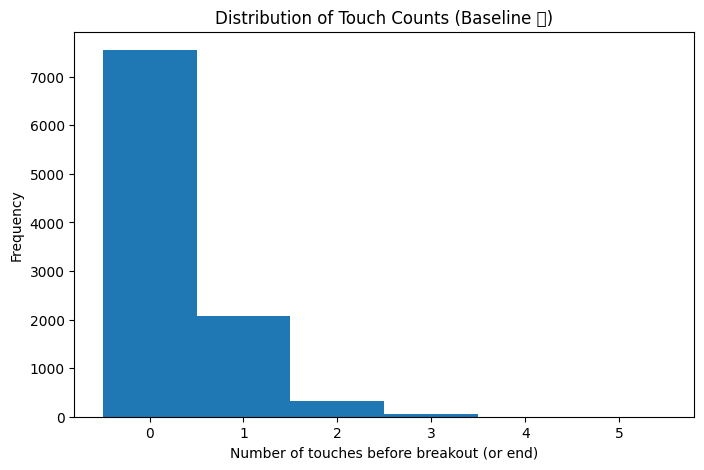

In [20]:
# Histogram of touches
plt.figure()
max_touches = min(10, touches_arr.max())
bins = np.arange(0, max_touches + 2) - 0.5
plt.hist(touches_arr, bins=bins)
plt.title("Distribution of Touch Counts (Baseline ￿)")
plt.xlabel("Number of touches before breakout (or end)")
plt.ylabel("Frequency")
plt.xticks(range(0, max_touches + 1))
plt.show()

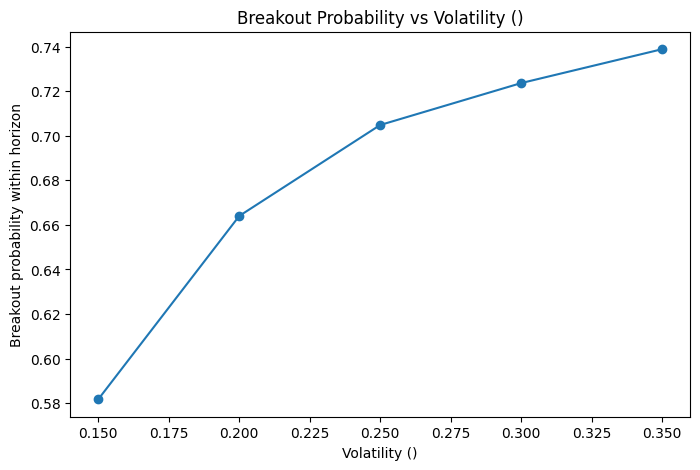

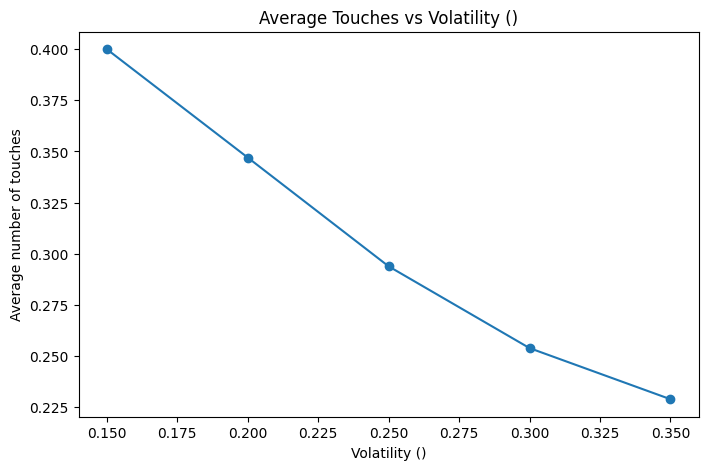

In [21]:
# Effect of volatility on breakout probability
sigmas = np.array([0.15, 0.20, 0.25, 0.30, 0.35])
probs = []
avg_touches = []
for s in sigmas:
    gbm_s = GeometricBrownianMotionSimulator(
    S0, mu, s, T, steps, rng)

    t_arr, b_arr, _ = monte_carlo_touches_breakout(
    gbm_s, n_sims // 2, R, eps)
    probs.append(b_arr.mean())
    avg_touches.append(t_arr.mean())

probs = np.array(probs)
avg_touches = np.array(avg_touches)

plt.figure()
plt.plot(sigmas, probs, marker='o')
plt.title("Breakout Probability vs Volatility ()")
plt.xlabel("Volatility ()")
plt.ylabel("Breakout probability within horizon")
plt.show()
plt.figure()
plt.plot(sigmas, avg_touches, marker='o')
plt.title("Average Touches vs Volatility ()")
plt.xlabel("Volatility ()")
plt.ylabel("Average number of touches")
plt.show()

The results show two key trends: 

- Higher volatility tends to increase the breakout probability, as larger price fluctuations make it easier to cross the resistance.

- The average number of touches also increases slightly, but most paths still have only a few attempts before a breakout (if any).

These visualizations summarize the dynamic behavior of GBM-simulated prices and illustrate how volatility affects the probability and frequency of resistance-level interactions.